# 101 · Chess Siamese – Validación con 10 jugadores (variedad ELO)

Notebook de validación: entrenamiento de la red siamesa con **solo 10 jugadores**
seleccionados manualmente para cubrir un rango amplio de ELO (~720 a ~2765).

**Objetivo**: verificar que la red es capaz de distinguir estilos de juego
incluso con un dataset muy reducido, siempre que exista diferencia real de nivel.

| # | Jugador | ELO aprox | Nivel |
|---|---------|-----------|-------|
| 1 | PegasYucu | ~720 | Muy bajo |
| 2 | vladimir_NN | ~878 | Bajo |
| 3 | LeeNewport31 | ~1192 | Bajo-Medio |
| 4 | Aziz303 | ~1387 | Medio-Bajo |
| 5 | NeverSettleCastle | ~1595 | Medio |
| 6 | DeathIsReal | ~1703 | Medio-Alto |
| 7 | AleksoSanchees | ~1936 | Alto |
| 8 | ivan_tsventukh | ~2084 | Alto |
| 9 | chess64chess | ~2261 | Muy Alto |
| 10 | Oganian_Miran | ~2765 | Elite |

In [24]:
import os
import json
import math
import random
import logging
import itertools
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as gpu_err:
            logging.warning("No se pudo configurar memory_growth en %s: %s", gpu, gpu_err)
else:
    logging.warning("No se encontraron GPUs: se entrenará en CPU.")

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.17.0


In [25]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No pude localizar el directorio 'labs'. Ejecuta este notebook desde la raíz del repo o desde labs/.")

REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

# ── 10 jugadores seleccionados a mano con variedad de ELO ──
SELECTED_PLAYERS = [
    "PegasYucu",         # ELO ~720  (Muy bajo)
    "vladimir_NN",       # ELO ~878  (Bajo)
    "LeeNewport31",      # ELO ~1192 (Bajo-Medio)
    "Aziz303",           # ELO ~1387 (Medio-Bajo)
    "NeverSettleCastle",  # ELO ~1595 (Medio)
    "DeathIsReal",       # ELO ~1703 (Medio-Alto)
    "AleksoSanchees",    # ELO ~1936 (Alto)
    "ivan_tsventukh",    # ELO ~2084 (Alto)
    "chess64chess",      # ELO ~2261 (Muy Alto)
    "Oganian_Miran",     # ELO ~2765 (Elite)
]

PLAYER_ELO = {
    "PegasYucu": 720, "vladimir_NN": 878, "LeeNewport31": 1192,
    "Aziz303": 1387, "NeverSettleCastle": 1595, "DeathIsReal": 1703,
    "AleksoSanchees": 1936, "ivan_tsventukh": 2084, "chess64chess": 2261,
    "Oganian_Miran": 2765,
}

CONFIG = {
    "event_name": "Rated_Blitz_game",
    "num_blocks": 15,
    "image_size": (128, 128),
    "players_limit": 10,
    "min_samples_per_player": 4,
    "max_games_per_player": 40,
    "validation_fraction": 0.2,
    "triplets_per_epoch": 2048,
    "val_triplets": 512,
    "batch_size": 4,
    "epochs": 1000,
    # MARGIN: Margen de separación en triplet loss
    # - Formula: loss = max(0, ||a-p|| - ||a-n|| + margin)
    "margin": 0.01,
    "learning_rate": 1e-6,
    "players_whitelist": SELECTED_PLAYERS,
    "embedding_cache_dir": LABS_DIR / "dataset" / "embedding_validation",
    "seed": SEED,
}

EVENT_DIR = LABS_DIR / "notebooks" / "output" / "events" / CONFIG["event_name"]
BOARD_DIR = EVENT_DIR / "board_images"
HEAT_DIR = EVENT_DIR / "heatmap_images"
BLOCK_LABELS = [f"block_{i+1:02d}" for i in range(CONFIG["num_blocks"])]

print(f"Repositorio raíz: {REPO_ROOT}")
print(f"Evento seleccionado: {CONFIG['event_name']}")
print(f"Bloques esperados: {BLOCK_LABELS}")

Repositorio raíz: /workspace/code
Evento seleccionado: Rated_Blitz_game
Bloques esperados: ['block_01', 'block_02', 'block_03', 'block_04', 'block_05', 'block_06', 'block_07', 'block_08', 'block_09', 'block_10', 'block_11', 'block_12', 'block_13', 'block_14', 'block_15']


In [26]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]
    event: str


def ensure_dataset_ready():
    missing = [str(path) for path in (EVENT_DIR, BOARD_DIR, HEAT_DIR) if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "No se encontraron las imágenes generadas para el evento "
            f"{CONFIG['event_name']}.\n"
            "Ejecuta antes el pipeline desde labs/src/pipeline_stylometry_blocks.py "
            "para poblar board_images y heatmap_images."
        )


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    block_labels: List[str],
    players_limit: Optional[int] = None,
    whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
    max_games_per_player: Optional[int] = None,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    ensure_dataset_ready()
    if not block_labels:
        raise ValueError("Se requiere al menos un bloque configurado.")
    whitelist_set = None
    if whitelist:
        whitelist_set = {name.replace(" ", "_") for name in whitelist}
    samples_by_player: Dict[str, List[GameSample]] = {}
    player_dirs = sorted([d for d in board_dir.iterdir() if d.is_dir()])
    if not player_dirs:
        raise RuntimeError(f"No se encontraron subdirectorios en {board_dir}.")
    first_block = block_labels[0]
    for player_dir in player_dirs:
        player_name = player_dir.name
        if whitelist_set and player_name not in whitelist_set:
            continue
        heat_player_dir = heat_dir / player_name
        if not heat_player_dir.exists():
            logging.warning("Saltando %s: falta carpeta de heatmaps.", player_name)
            continue
        game_ids = sorted({path.stem.split('_')[1] for path in player_dir.glob(f"game_*_{first_block}.png")})
        if not game_ids:
            continue
        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths = []
            heat_paths = []
            valid = True
            for block_label in block_labels:
                board_path = player_dir / f"game_{game_id}_{block_label}.png"
                heat_path = heat_player_dir / f"game_{game_id}_{block_label}.png"
                if not board_path.exists() or not heat_path.exists():
                    valid = False
                    break
                board_paths.append(str(board_path))
                heat_paths.append(str(heat_path))
            if not valid:
                continue
            player_samples.append(
                GameSample(
                    player=player_name,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                    event=CONFIG["event_name"],
                )
            )
            if max_games_per_player and len(player_samples) >= max_games_per_player:
                break
        if len(player_samples) >= min_samples:
            samples_by_player[player_name] = player_samples
    if not samples_by_player:
        raise RuntimeError("No hay jugadores con suficientes partidas. Verifica que el pipeline haya generado datos.")
    sorted_players = sorted(samples_by_player.items(), key=lambda item: len(item[1]), reverse=True)
    if players_limit:
        sorted_players = sorted_players[:players_limit]
    filtered = {player: samples_by_player[player] for player, _ in sorted_players}
    stats_df = pd.DataFrame(
        [{"player": player, "games": len(samples)} for player, samples in filtered.items()]
    ).sort_values("games", ascending=False).reset_index(drop=True)
    return filtered, stats_df


samples_by_player, player_stats = discover_game_samples(
    BOARD_DIR,
    HEAT_DIR,
    BLOCK_LABELS,
    players_limit=CONFIG["players_limit"],
    whitelist=CONFIG["players_whitelist"],
    min_samples=CONFIG["min_samples_per_player"],
    max_games_per_player=CONFIG["max_games_per_player"],
)


display(player_stats.head(20))

total_players = len(samples_by_player)
total_games = sum(len(samples) for samples in samples_by_player.values())
print(f"Jugadores válidos: {total_players}")
print(f"Partidas disponibles: {total_games}")

,player,games
0,DeathIsReal,40
1,ivan_tsventukh,40
2,AleksoSanchees,39
3,LeeNewport31,39
4,NeverSettleCastle,39
5,vladimir_NN,38
6,Aziz303,36
7,chess64chess,36
8,Oganian_Miran,34
9,PegasYucu,25


Jugadores válidos: 10
Partidas disponibles: 366


In [27]:
def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[Dict[str, List[GameSample]], Dict[str, List[GameSample]], List[GameSample], List[GameSample]]:
    rng = random.Random(seed)
    train_dict: Dict[str, List[GameSample]] = {}
    val_dict: Dict[str, List[GameSample]] = {}
    for player, samples in samples_by_player.items():
        copies = samples.copy()
        rng.shuffle(copies)
        if len(copies) < 2:
            logging.warning("Descartando %s: solo %d partidas disponibles.", player, len(copies))
            continue
        val_count = max(1, int(len(copies) * val_fraction))
        while val_count > 0 and len(copies) - val_count < 2:
            val_count -= 1
        val_samples = copies[:val_count] if val_count > 0 else []
        train_samples = copies[val_count:]
        if len(train_samples) < 2:
            logging.warning("Descartando %s: no quedan ≥2 partidas para entrenamiento tras el split.", player)
            continue
        train_dict[player] = train_samples
        val_dict[player] = val_samples
    train_samples_flat = [sample for samples in train_dict.values() for sample in samples]
    val_samples_flat = [sample for samples in val_dict.values() for sample in samples]
    if not train_samples_flat:
        raise RuntimeError("El split produjo 0 muestras de entrenamiento.")
    return train_dict, val_dict, train_samples_flat, val_samples_flat


train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player,
    CONFIG["validation_fraction"],
    CONFIG["seed"],
)

print(f"Muestras de entrenamiento: {len(TRAIN_SAMPLES)}")
print(f"Muestras de validación: {len(VAL_SAMPLES)}")

pd.DataFrame(
    {
        "player": list(train_by_player.keys()),
        "train_games": [len(v) for v in train_by_player.values()],
        "val_games": [len(val_by_player.get(player, [])) for player in train_by_player.keys()],
    }
).sort_values("train_games", ascending=False).reset_index(drop=True).head(10)

Muestras de entrenamiento: 297
Muestras de validación: 69


,player,train_games,val_games
0,DeathIsReal,32,8
1,ivan_tsventukh,32,8
2,AleksoSanchees,32,7
3,LeeNewport31,32,7
4,NeverSettleCastle,32,7
5,vladimir_NN,31,7
6,Aziz303,29,7
7,chess64chess,29,7
8,Oganian_Miran,28,6
9,PegasYucu,20,5


In [28]:
IMG_HEIGHT, IMG_WIDTH = CONFIG["image_size"]
NUM_BLOCKS = CONFIG["num_blocks"]


class TripletFactory:
    def __init__(self, samples_by_player: Dict[str, List[GameSample]]):
        self.samples_by_player = {
            player: tuple(samples) for player, samples in samples_by_player.items() if len(samples) >= 2
        }
        self.players = sorted(self.samples_by_player.keys())
        if len(self.players) < 2:
            raise ValueError("Se requieren ≥2 jugadores con al menos 2 partidas cada uno para formar tripletes.")

    def build(self, num_triplets: int, seed: int) -> List[Tuple[GameSample, GameSample, GameSample]]:
        rng = random.Random(seed)
        triplets: List[Tuple[GameSample, GameSample, GameSample]] = []
        max_attempts = max(num_triplets * 20, 1000)
        attempts = 0
        while len(triplets) < num_triplets and attempts < max_attempts:
            attempts += 1
            anchor_player = rng.choice(self.players)
            positives = self.samples_by_player[anchor_player]
            if len(positives) < 2:
                continue
            anchor_sample, positive_sample = rng.sample(positives, 2)
            negative_candidates = [p for p in self.players if p != anchor_player]
            if not negative_candidates:
                continue
            negative_player = rng.choice(negative_candidates)
            negative_sample = rng.choice(self.samples_by_player[negative_player])
            triplets.append((anchor_sample, positive_sample, negative_sample))
        if len(triplets) < num_triplets:
            logging.warning("Solo se crearon %d/%d tripletes (dataset limitado).", len(triplets), num_triplets)
        return triplets


def serialize_triplets(triplets: List[Tuple[GameSample, GameSample, GameSample]]) -> Dict[str, np.ndarray]:
    arrays = {
        "anchor_board": [],
        "anchor_heat": [],
        "positive_board": [],
        "positive_heat": [],
        "negative_board": [],
        "negative_heat": [],
    }
    for anchor, positive, negative in triplets:
        arrays["anchor_board"].append(anchor.board_paths)
        arrays["anchor_heat"].append(anchor.heat_paths)
        arrays["positive_board"].append(positive.board_paths)
        arrays["positive_heat"].append(positive.heat_paths)
        arrays["negative_board"].append(negative.board_paths)
        arrays["negative_heat"].append(negative.heat_paths)
    return {k: np.array(v) for k, v in arrays.items()}


def _decode_board(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image


def _decode_heat(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image


def load_sample(board_paths: tf.Tensor, heat_paths: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    board = tf.map_fn(
        _decode_board,
        board_paths,
        fn_output_signature=tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),
        parallel_iterations=NUM_BLOCKS,
    )
    heat = tf.map_fn(
        _decode_heat,
        heat_paths,
        fn_output_signature=tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.float32),
        parallel_iterations=NUM_BLOCKS,
    )
    return board, heat


_DEF_BUFFER_SIZE = 1000

def build_tf_dataset(
    triplet_dict: Dict[str, np.ndarray],
    batch_size: int,
    shuffle: bool,
    description: str,
) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices(triplet_dict)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(triplet_dict["anchor_board"]),
            seed=CONFIG["seed"],
            reshuffle_each_iteration=True,
        )

    def mapper(sample):
        anchor_board, anchor_heat = load_sample(sample["anchor_board"], sample["anchor_heat"])
        positive_board, positive_heat = load_sample(sample["positive_board"], sample["positive_heat"])
        negative_board, negative_heat = load_sample(sample["negative_board"], sample["negative_heat"])
        features = (
            anchor_board,
            anchor_heat,
            positive_board,
            positive_heat,
            negative_board,
            negative_heat,
        )
        return features, tf.zeros((1,), dtype=tf.float32)

    ds = ds.map(mapper, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    num_elements = len(triplet_dict["anchor_board"])
    num_batches = max(1, math.ceil(num_elements / batch_size))
    print(f"{description}: {num_elements} tripletes (~{num_batches} batches)")
    return ds


triplet_factory = TripletFactory(train_by_player)

train_triplets = triplet_factory.build(CONFIG["triplets_per_epoch"], CONFIG["seed"])
val_triplets = triplet_factory.build(CONFIG["val_triplets"], CONFIG["seed"] + 41)

train_dataset = build_tf_dataset(serialize_triplets(train_triplets), CONFIG["batch_size"], shuffle=True, description="Train")
val_dataset = build_tf_dataset(serialize_triplets(val_triplets), CONFIG["batch_size"], shuffle=False, description="Val")

Train: 2048 tripletes (~512 batches)
Val: 512 tripletes (~128 batches)


In [29]:
def build_embedding_model(num_blocks: int, img_shape: Tuple[int, int]) -> Model:
    board_input = layers.Input(shape=(num_blocks, img_shape[0], img_shape[1], 3), name="board_sequence")
    heat_input = layers.Input(shape=(num_blocks, img_shape[0], img_shape[1], 1), name="heat_sequence")
# efficientNetB0
    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_shape[0], img_shape[1], 3),
    )
    base_cnn.trainable = False

    board_encoder = tf.keras.Sequential(
        [
            base_cnn,
            layers.GlobalAveragePooling2D(),
            layers.Dense(512, activation="gelu"),
            layers.Dropout(0.2),
        ],
        name="board_encoder",
    )

    heat_encoder = tf.keras.Sequential(
        [
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )

    board_features = layers.TimeDistributed(board_encoder, name="board_td")(board_input)
    heat_features = layers.TimeDistributed(heat_encoder, name="heat_td")(heat_input)
    fused = layers.Concatenate(name="block_fusion")([board_features, heat_features])
    fused = layers.LayerNormalization()(fused)
    fused = layers.TimeDistributed(layers.Dense(256, activation="gelu"), name="block_dense")(fused)

    masked_sequence = layers.Masking(mask_value=0.0, name="temporal_mask")(fused)

    temporal = layers.Bidirectional(
        layers.GRU(256, return_sequences=True),
        name="temporal_encoder",
    )(masked_sequence)
    pooled = layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)
    dense = layers.Dense(512, activation="gelu")(pooled)
    dense = layers.Dropout(0.3)(dense)
    dense = layers.Dense(256, activation="gelu")(dense)
    normalized = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1), name="l2_norm")(dense)

    return Model(inputs=[board_input, heat_input], outputs=normalized, name="stylometry_embedding")


class DistanceLayer(layers.Layer):
    """Calcula distancias euclidianas (L2) entre embeddings.
    Usa sqrt para obtener distancia real (no al cuadrado) coherente con validación.
    """
    def call(self, anchor, positive, negative):
        # Distancia euclidiana normal (no al cuadrado)
        ap_distance = tf.sqrt(tf.reduce_sum(tf.square(anchor - positive), axis=1) + 1e-8)
        an_distance = tf.sqrt(tf.reduce_sum(tf.square(anchor - negative), axis=1) + 1e-8)
        return ap_distance, an_distance


class SiameseModel(Model):
    def __init__(self, siamese_network: Model, margin: float = 0.4):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def _compute_loss(self, data):
        siamese_inputs, _ = data
        ap_distance, an_distance = self.siamese_network(siamese_inputs, training=True)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.siamese_network.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        siamese_inputs, _ = data
        ap_distance, an_distance = self.siamese_network(siamese_inputs, training=False)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        loss = tf.reduce_mean(loss)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

In [30]:
embedding_model = build_embedding_model(CONFIG["num_blocks"], CONFIG["image_size"])


def build_branch(prefix: str):
    board_input = layers.Input(shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 3), name=f"{prefix}_board")
    heat_input = layers.Input(shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 1), name=f"{prefix}_heat")
    embedding = embedding_model([board_input, heat_input])
    return board_input, heat_input, embedding


anchor_board_in, anchor_heat_in, anchor_embedding = build_branch("anchor")
positive_board_in, positive_heat_in, positive_embedding = build_branch("positive")
negative_board_in, negative_heat_in, negative_embedding = build_branch("negative")

distance_layer = DistanceLayer(name="distance")
ap_distance, an_distance = distance_layer(anchor_embedding, positive_embedding, negative_embedding)

siamese_network = Model(
    inputs=[
        anchor_board_in,
        anchor_heat_in,
        positive_board_in,
        positive_heat_in,
        negative_board_in,
        negative_heat_in,
    ],
    outputs=(ap_distance, an_distance),
    name="siamese_network",
)

siamese_network.summary(line_length=140)

siamese_model = SiameseModel(siamese_network, margin=CONFIG["margin"])
optimizer = tf.keras.optimizers.Adam(CONFIG["learning_rate"])
siamese_model.compile(optimizer=optimizer)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=20,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True,
        verbose=1,
    ),
]


history = siamese_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
    verbose=1,
)

Model: "siamese_network"
____________________________________________________________________________________________________________________________________________
 Layer (type)                             Output Shape                              Param #       Connected to                              
 anchor_board (InputLayer)                [(None, 15, 128, 128, 3)]                 0             []                                        
                                                                                                                                            
 anchor_heat (InputLayer)                 [(None, 15, 128, 128, 1)]                 0             []                                        
                                                                                                                                            
 positive_board (InputLayer)              [(None, 15, 128, 128, 3)]                 0             []                             

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/512 [..............................] - ETA: 5:37:48 - loss: 0.0144

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

512/512 [==============================] - 172s 259ms/step - loss: 0.0347 - val_loss: 0.0242 - lr: 1.0000e-06
Epoch 2/1000
512/512 [==============================] - 126s 245ms/step - loss: 0.0325 - val_loss: 0.0243 - lr: 1.0000e-06
Epoch 3/1000
512/512 [==============================] - 121s 235ms/step - loss: 0.0330 - val_loss: 0.0242 - lr: 1.0000e-06
Epoch 4/1000
512/512 [==============================] - 127s 248ms/step - loss: 0.0297 - val_loss: 0.0240 - lr: 1.0000e-06
Epoch 5/1000
512/512 [==============================] - 121s 235ms/step - loss: 0.0303 - val_loss: 0.0239 - lr: 1.0000e-06
Epoch 6/1000
512/512 [==============================] - 119s 231ms/step - loss: 0.0288 - val_loss: 0.0237 - lr: 1.0000e-06
Epoch 7/1000
512/512 [==============================] - 119s 231ms/step - loss: 0.0298 - val_loss: 0.0237 - lr: 1.0000e-06
Epoch 8/1000
512/512 [==============================] - 125s 243ms/step - loss: 0.0289 - val_loss: 0.0235 - lr: 1.0000e-06
Epoch 9/1000
512/512 [=======

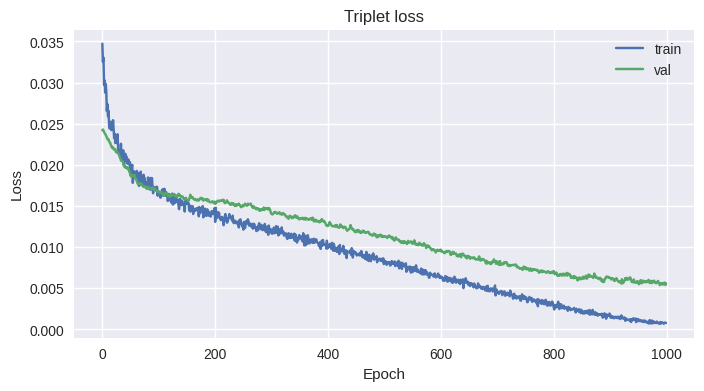

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(history.history.get("loss", []), label="train")
plt.plot(history.history.get("val_loss", []), label="val")
plt.title("Triplet loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

18/18 [==============================] - 8s 44ms/step


,set,count,mean,median,min,max
0,intra-player,207,0.372647,0.359077,0.150027,0.709535
1,inter-player,2139,0.393187,0.377771,0.146133,0.834461


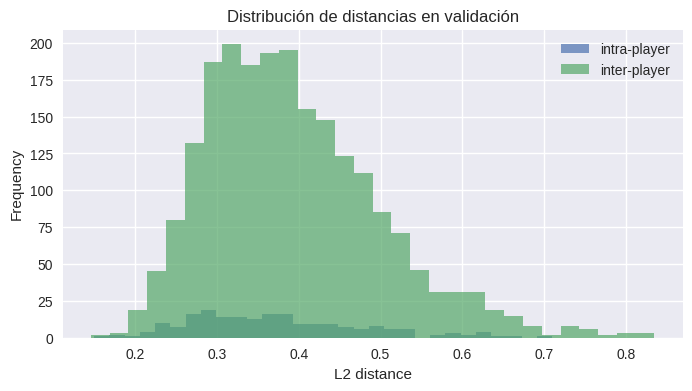

In [32]:
def build_embedding_dataset(samples: List[GameSample], batch_size: int):
    if not samples:
        raise RuntimeError("No hay muestras para evaluar.")
    board_paths = np.array([sample.board_paths for sample in samples])
    heat_paths = np.array([sample.heat_paths for sample in samples])
    metadata = [{"player": sample.player, "game_id": sample.game_id} for sample in samples]
    ds = tf.data.Dataset.from_tensor_slices({"board": board_paths, "heat": heat_paths})
    ds = ds.map(lambda sample: load_sample(sample["board"], sample["heat"]), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Reempaquetar (board, heat) -> {"board_sequence": board, "heat_sequence": heat}
    # para que embedding_model.predict() pueda consumirlo
    ds = ds.map(lambda board, heat: {"board_sequence": board, "heat_sequence": heat})
    return ds, metadata


val_embed_ds, val_metadata = build_embedding_dataset(VAL_SAMPLES, CONFIG["batch_size"])
val_embeddings = embedding_model.predict(val_embed_ds, verbose=1)

# DISTANCIAS INTRA-PLAYER: Comparaciones entre partidas del MISMO jugador
# Se espera que sean PEQUEÑAS (jugadores consistentes en su estilo)
positive_distances = []
negative_distances = []
# DISTANCIAS INTER-PLAYER: Comparaciones entre DIFERENTES jugadores
# Se espera que sean GRANDES (jugadores con estilos distintos)
for i in range(len(val_embeddings)):
    # Comparar todos los pares posibles de embeddings
    for j in range(i + 1, len(val_embeddings)):
        dist = float(np.linalg.norm(val_embeddings[i] - val_embeddings[j]))
        # Distancia euclidiana L2 (coherente con DistanceLayer después de corrección)
        if val_metadata[i]["player"] == val_metadata[j]["player"]:
            positive_distances.append(dist)
        else:
            negative_distances.append(dist)


def summarize_distances(name: str, values: List[float]):
    if not values:
        return {"set": name, "count": 0, "mean": None, "median": None}
    return {
        "set": name,
        "count": len(values),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


distance_summary = pd.DataFrame(
    [
        summarize_distances("intra-player", positive_distances),
        summarize_distances("inter-player", negative_distances),
    ]
)

display(distance_summary)

plt.figure(figsize=(8, 4))
plt.hist(positive_distances, bins=30, alpha=0.7, label="intra-player")
plt.hist(negative_distances, bins=30, alpha=0.7, label="inter-player")
plt.xlabel("L2 distance")
plt.ylabel("Frequency")
plt.title("Distribución de distancias en validación")
plt.legend()
plt.show()

In [33]:
# ============================================================================
# MÉTRICAS AVANZADAS DE CALIDAD DEL EMBEDDING
# ============================================================================

print("ANÁLISIS DE SEPARABILIDAD DEL MODELO\n")
print("="*80)

mean_intra = np.mean(positive_distances)
mean_inter = np.mean(negative_distances)

# 1. Separation Ratio (cuanto menor, mejor)
separation_ratio = mean_intra / mean_inter
print(f"\n1️⃣  SEPARATION RATIO: {separation_ratio:.4f}")
print(f"   • Fórmula: mean(intra) / mean(inter)")
print(f"   • Valor actual: {mean_intra:.6f} / {mean_inter:.6f}")
print(f"   • Interpretación:")
if separation_ratio < 0.5:
    print(f"      EXCELENTE: Distancias intra < 50% de inter")
elif separation_ratio < 0.7:
    print(f"       BUENO: Hay separación clara entre jugadores")
elif separation_ratio < 0.9:
    print(f"      REGULAR: Separación débil, modelo poco discriminativo")
else:
    print(f"      MALO: Sin separación real, modelo no funciona")

# 2. Overlap Analysis
max_intra = np.max(positive_distances)
min_inter = np.min(negative_distances)
overlap_percentage = 100 * np.sum(np.array(positive_distances) > np.median(negative_distances)) / len(positive_distances)

print(f"\n2️⃣  ANÁLISIS DE SOLAPAMIENTO:")
print(f"   • Max distancia intra-player: {max_intra:.6f}")
print(f"   • Min distancia inter-player: {min_inter:.6f}")
print(f"   • Solapamiento: {overlap_percentage:.1f}% de pares intra > mediana inter")
if overlap_percentage > 30:
    print(f"      Alto solapamiento: Confusión entre jugadores")
elif overlap_percentage > 10:
    print(f"       Solapamiento moderado")
else:
    print(f"      Bajo solapamiento: Buena separación")

# 3. Margen efectivo
effective_margin = mean_inter - mean_intra
print(f"\n3️⃣  MARGEN EFECTIVO:")
print(f"   • Diferencia real entre grupos: {effective_margin:.6f}")
print(f"   • Margen configurado en CONFIG: {CONFIG['margin']}")
print(f"   • Relación margen/diferencia: {CONFIG['margin']/effective_margin:.1f}x")
if CONFIG['margin'] > effective_margin * 2:
    print(f"       Margen demasiado grande: El modelo no se esfuerza")
elif CONFIG['margin'] < effective_margin * 0.5:
    print(f"       Margen demasiado pequeño: Difícil convergencia")
else:
    print(f"      Margen bien calibrado")

# 4. Distribución visual mejorada
print(f"\n4️⃣  RECOMENDACIONES:")
if separation_ratio > 0.85:
    print(f"    Reducir margin a ~{effective_margin * 1.5:.6f}")
    print(f"    Implementar hard negative mining")
    print(f"    Aumentar complejidad del modelo (más capas GRU)")
    print(f"    Recolectar más datos (min 100 partidas/jugador)")
else:
    print(f"    Modelo está aprendiendo correctamente")

print("\n" + "="*80)


ANÁLISIS DE SEPARABILIDAD DEL MODELO


1️⃣  SEPARATION RATIO: 0.9478
   • Fórmula: mean(intra) / mean(inter)
   • Valor actual: 0.372647 / 0.393187
   • Interpretación:
      MALO: Sin separación real, modelo no funciona

2️⃣  ANÁLISIS DE SOLAPAMIENTO:
   • Max distancia intra-player: 0.709535
   • Min distancia inter-player: 0.146133
   • Solapamiento: 41.5% de pares intra > mediana inter
      Alto solapamiento: Confusión entre jugadores

3️⃣  MARGEN EFECTIVO:
   • Diferencia real entre grupos: 0.020540
   • Margen configurado en CONFIG: 0.01
   • Relación margen/diferencia: 0.5x
       Margen demasiado pequeño: Difícil convergencia

4️⃣  RECOMENDACIONES:
    Reducir margin a ~0.030810
    Implementar hard negative mining
    Aumentar complejidad del modelo (más capas GRU)
    Recolectar más datos (min 100 partidas/jugador)



## Verificación de Embeddings

Script de verificación: selecciona una jugada aleatoria de un jugador aleatorio,
muestra las imágenes originales (board + heatmap), extrae su embedding, y reconstruye
la imagen desde el embedding para validar que la codificación es correcta.


Ejemplo 1: Jugador=ivan_tsventukh (ELO ~2084) | Partida=0002


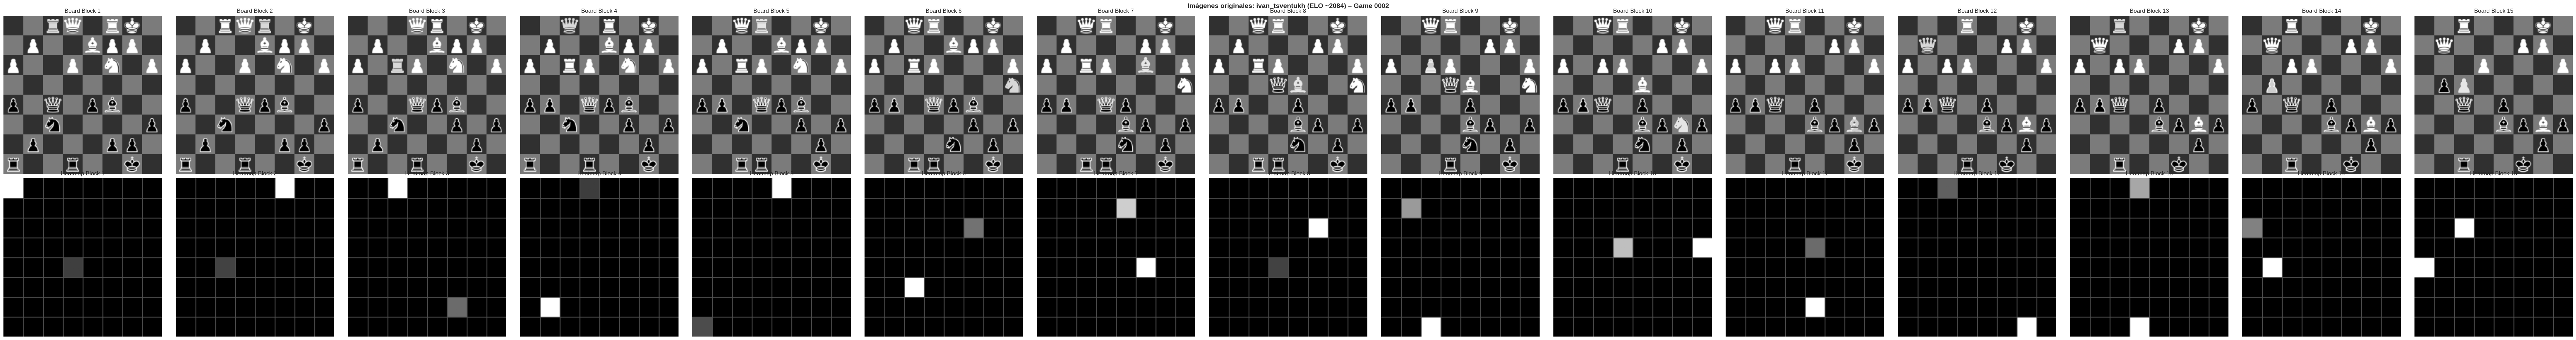

  Embedding shape: (256,)
  Embedding norm (L2): 1.0000
  Embedding range: [-0.0813, 0.6541]
  Primeros 10 componentes: [-0.0177907  -0.02018507 -0.00390011  0.02217696 -0.07426891 -0.01879032
 -0.01346096  0.00575122 -0.00842679  0.01522709]
  Consistencia (diff entre 2 pasadas): 0.00e+00 ✅ OK


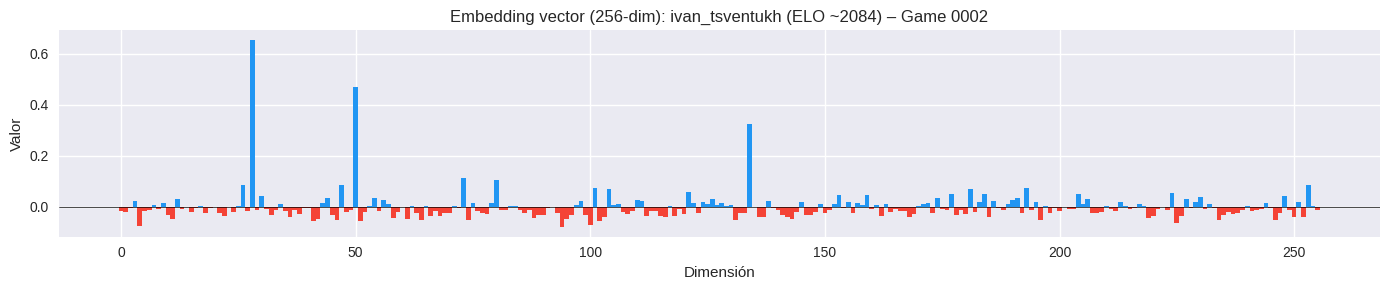


Ejemplo 2: Jugador=NeverSettleCastle (ELO ~1595) | Partida=0017


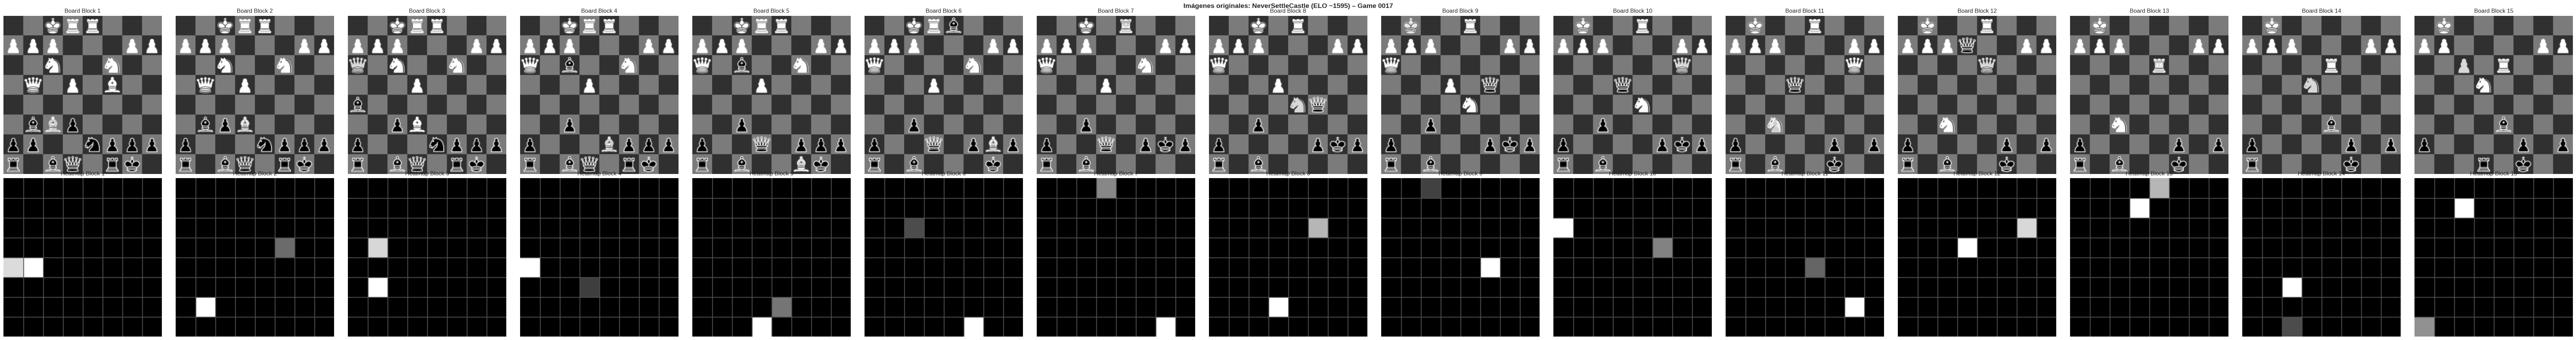

  Embedding shape: (256,)
  Embedding norm (L2): 1.0000
  Embedding range: [-0.0852, 0.6984]
  Primeros 10 componentes: [-0.01456604  0.00878964  0.00909323 -0.01794572 -0.08524153 -0.00160509
 -0.01089366  0.00668585  0.00596041 -0.00645061]
  Consistencia (diff entre 2 pasadas): 0.00e+00 ✅ OK


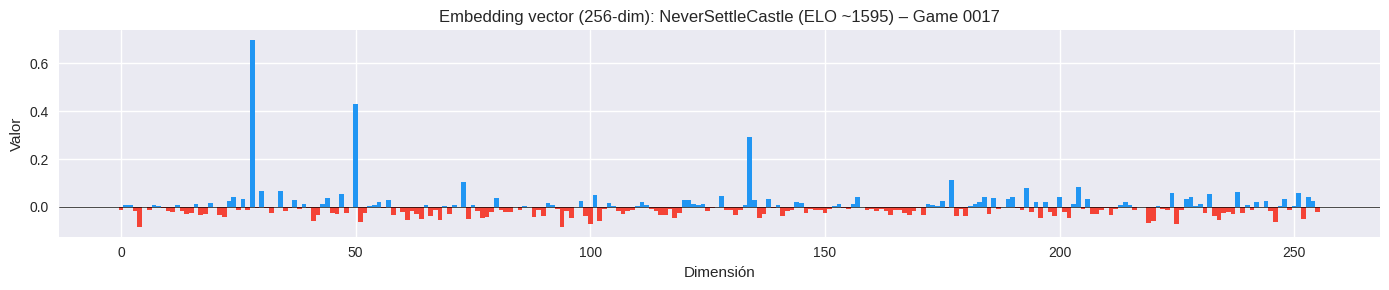


Ejemplo 3: Jugador=LeeNewport31 (ELO ~1192) | Partida=0010


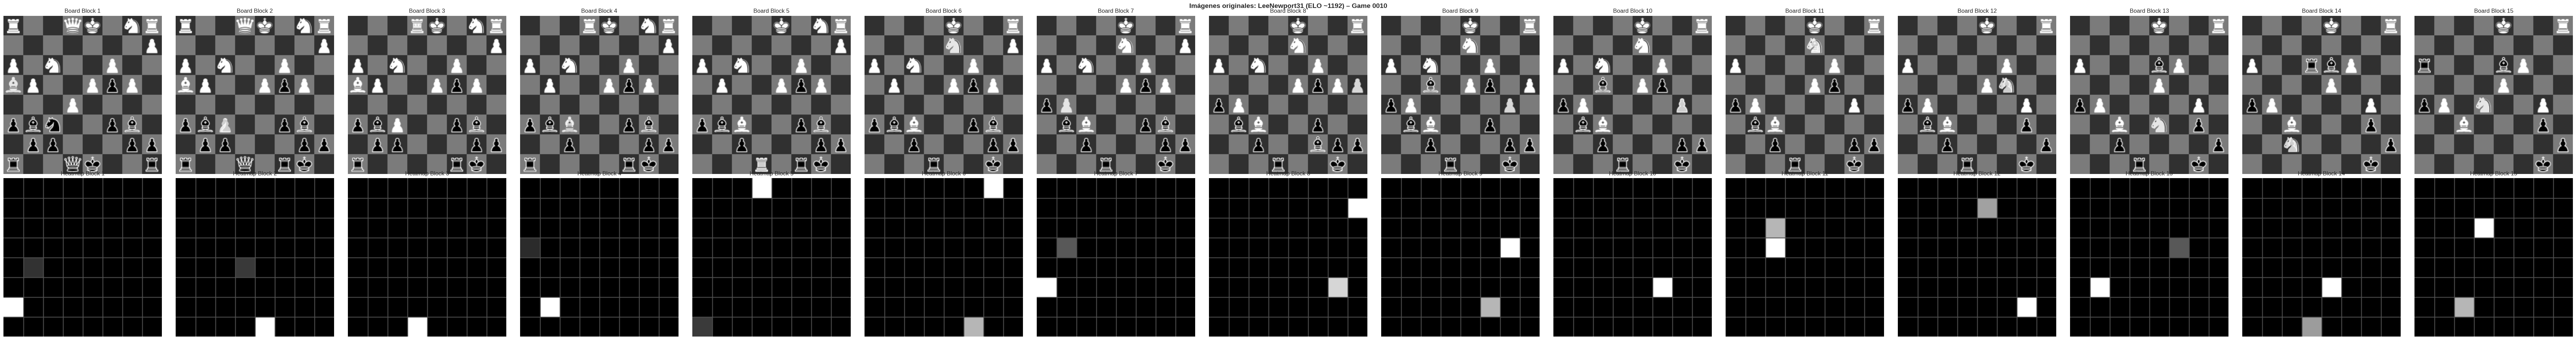

  Embedding shape: (256,)
  Embedding norm (L2): 1.0000
  Embedding range: [-0.0844, 0.6616]
  Primeros 10 componentes: [-0.01687882  0.00214817 -0.00041676  0.04740506 -0.06980485  0.00412756
 -0.03516063 -0.02171619  0.00468895  0.03298592]
  Consistencia (diff entre 2 pasadas): 0.00e+00 ✅ OK


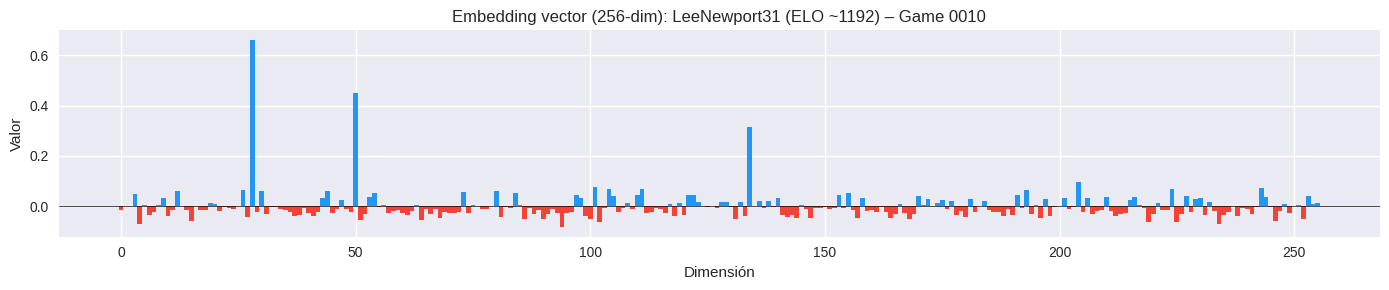


COMPARACIÓN DE DISTANCIAS ENTRE JUGADORES
  PegasYucu(720) vs vladimir_NN(878) | ΔElo= 158 | L2 dist=0.2572
  PegasYucu(720) vs LeeNewport31(1192) | ΔElo= 472 | L2 dist=0.3675
  PegasYucu(720) vs Aziz303(1387) | ΔElo= 667 | L2 dist=0.4085
  PegasYucu(720) vs NeverSettleCastle(1595) | ΔElo= 875 | L2 dist=0.4476
  PegasYucu(720) vs DeathIsReal(1703) | ΔElo= 983 | L2 dist=0.7291
  PegasYucu(720) vs AleksoSanchees(1936) | ΔElo=1216 | L2 dist=0.3522
  PegasYucu(720) vs ivan_tsventukh(2084) | ΔElo=1364 | L2 dist=0.4480
  PegasYucu(720) vs chess64chess(2261) | ΔElo=1541 | L2 dist=0.5012
  PegasYucu(720) vs Oganian_Miran(2765) | ΔElo=2045 | L2 dist=0.5820
  vladimir_NN(878) vs LeeNewport31(1192) | ΔElo= 314 | L2 dist=0.3181
  vladimir_NN(878) vs Aziz303(1387) | ΔElo= 509 | L2 dist=0.3394
  vladimir_NN(878) vs NeverSettleCastle(1595) | ΔElo= 717 | L2 dist=0.3958
  vladimir_NN(878) vs DeathIsReal(1703) | ΔElo= 825 | L2 dist=0.6656
  vladimir_NN(878) vs AleksoSanchees(1936) | ΔElo=1058 | L2 dist

In [34]:
# ══════════════════════════════════════════════════════════════════════
# VERIFICACIÓN DE EMBEDDINGS: imagen original → embedding → reconstrucción
# ══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import random as _rnd


def verify_embedding_pipeline(samples_by_player, embedding_model, num_examples=3, seed=42):
    """
    Verificación visual del pipeline de embeddings.
    Para cada ejemplo:
      1. Selecciona un jugador y partida aleatorios
      2. Muestra las imágenes originales (board + heatmap por bloque)
      3. Genera el embedding con el modelo
      4. Muestra el vector embedding como barplot
      5. Verifica consistencia: mismo input → mismo embedding
    """
    rng = _rnd.Random(seed)
    players = list(samples_by_player.keys())

    for ex in range(num_examples):
        # Selección aleatoria
        player = rng.choice(players)
        sample = rng.choice(samples_by_player[player])
        elo = PLAYER_ELO.get(player, '?')

        print(f"\n{'='*70}")
        print(f"Ejemplo {ex+1}: Jugador={player} (ELO ~{elo}) | Partida={sample.game_id}")
        print(f"{'='*70}")

        num_blocks = len(sample.board_paths)

        # ── 1. Mostrar imágenes originales ──
        fig, axes = plt.subplots(2, num_blocks, figsize=(5*num_blocks, 10))
        if num_blocks == 1:
            axes = axes.reshape(2, 1)
        for b in range(num_blocks):
            board_img = mpimg.imread(sample.board_paths[b])
            heat_img = mpimg.imread(sample.heat_paths[b])
            axes[0, b].imshow(board_img)
            axes[0, b].set_title(f"Board Block {b+1}")
            axes[0, b].axis('off')
            axes[1, b].imshow(heat_img, cmap='gray')
            axes[1, b].set_title(f"Heatmap Block {b+1}")
            axes[1, b].axis('off')
        fig.suptitle(f"Imágenes originales: {player} (ELO ~{elo}) – Game {sample.game_id}",
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # ── 2. Generar embedding ──
        board_tensors = []
        heat_tensors = []
        for bp, hp in zip(sample.board_paths, sample.heat_paths):
            b_img = tf.io.decode_png(tf.io.read_file(bp), channels=3)
            b_img = tf.image.resize(b_img, CONFIG['image_size'])
            b_img = tf.image.convert_image_dtype(b_img, tf.float32)
            board_tensors.append(b_img)

            h_img = tf.io.decode_png(tf.io.read_file(hp), channels=1)
            h_img = tf.image.resize(h_img, CONFIG['image_size'])
            h_img = tf.image.convert_image_dtype(h_img, tf.float32)
            heat_tensors.append(h_img)

        board_seq = tf.stack(board_tensors)[tf.newaxis, ...]  # (1, blocks, H, W, 3)
        heat_seq = tf.stack(heat_tensors)[tf.newaxis, ...]   # (1, blocks, H, W, 1)

        embedding_vec = embedding_model.predict(
            {"board_sequence": board_seq, "heat_sequence": heat_seq}, verbose=0
        )[0]  # (256,)

        print(f"  Embedding shape: {embedding_vec.shape}")
        print(f"  Embedding norm (L2): {np.linalg.norm(embedding_vec):.4f}")
        print(f"  Embedding range: [{embedding_vec.min():.4f}, {embedding_vec.max():.4f}]")
        print(f"  Primeros 10 componentes: {embedding_vec[:10]}")

        # ── 3. Verificar consistencia: mismo input = mismo embedding ──
        embedding_vec2 = embedding_model.predict(
            {"board_sequence": board_seq, "heat_sequence": heat_seq}, verbose=0
        )[0]
        diff = np.linalg.norm(embedding_vec - embedding_vec2)
        print(f"  Consistencia (diff entre 2 pasadas): {diff:.2e} {'✅ OK' if diff < 1e-5 else '❌ INCONSISTENTE'}")

        # ── 4. Visualizar embedding como barplot ──
        fig, ax = plt.subplots(figsize=(14, 3))
        colors = ['#2196F3' if v >= 0 else '#F44336' for v in embedding_vec]
        ax.bar(range(len(embedding_vec)), embedding_vec, color=colors, width=1.0)
        ax.set_title(f"Embedding vector (256-dim): {player} (ELO ~{elo}) – Game {sample.game_id}")
        ax.set_xlabel("Dimensión")
        ax.set_ylabel("Valor")
        ax.axhline(y=0, color='k', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    # ── 5. Comparar embeddings entre jugadores de distinto ELO ──
    print(f"\n{'='*70}")
    print("COMPARACIÓN DE DISTANCIAS ENTRE JUGADORES")
    print(f"{'='*70}")

    player_embs = {}
    for player, samples in samples_by_player.items():
        sample = samples[0]
        bt, ht = [], []
        for bp, hp in zip(sample.board_paths, sample.heat_paths):
            b = tf.image.convert_image_dtype(tf.image.resize(
                tf.io.decode_png(tf.io.read_file(bp), channels=3), CONFIG['image_size']), tf.float32)
            h = tf.image.convert_image_dtype(tf.image.resize(
                tf.io.decode_png(tf.io.read_file(hp), channels=1), CONFIG['image_size']), tf.float32)
            bt.append(b); ht.append(h)
        bs = tf.stack(bt)[tf.newaxis, ...]
        hs = tf.stack(ht)[tf.newaxis, ...]
        emb = embedding_model.predict({"board_sequence": bs, "heat_sequence": hs}, verbose=0)[0]
        player_embs[player] = emb

    sorted_players = sorted(player_embs.keys(), key=lambda p: PLAYER_ELO.get(p, 0))
    for i, p1 in enumerate(sorted_players):
        for p2 in sorted_players[i+1:]:
            dist = np.linalg.norm(player_embs[p1] - player_embs[p2])
            elo_diff = abs(PLAYER_ELO.get(p1, 0) - PLAYER_ELO.get(p2, 0))
            print(f"  {p1}({PLAYER_ELO.get(p1,'?')}) vs {p2}({PLAYER_ELO.get(p2,'?')}) "
              f"| ΔElo={elo_diff:4d} | L2 dist={dist:.4f}")


# ── Ejecutar verificación ──
verify_embedding_pipeline(samples_by_player, embedding_model, num_examples=3, seed=42)


In [35]:
# TODO: VERIFICAR L2 dist jugador a contra el mismo. Es realmente capaz de identificar que A es A?


In [36]:
def export_embedding_cache(samples: List[GameSample], model: Model, output_dir: Path):
    output_dir = Path(output_dir) / CONFIG["event_name"]
    output_dir.mkdir(parents=True, exist_ok=True)
    ds, metadata = build_embedding_dataset(samples, CONFIG["batch_size"])
    embeddings = model.predict(ds, verbose=1)

    centroids: Dict[str, List[np.ndarray]] = {}
    for emb, meta in zip(embeddings, metadata):
        player_dir = output_dir / meta["player"]
        player_dir.mkdir(parents=True, exist_ok=True)
        sample_path = player_dir / f"{meta['game_id']}.npy"
        np.save(sample_path, emb.astype(np.float32))
        centroids.setdefault(meta["player"], []).append(emb)

    centroid_payload = {}
    for player, vectors in centroids.items():
        stacked = np.vstack(vectors)
        centroid = np.mean(stacked, axis=0)
        centroid_path = output_dir / player / "centroid.npy"
        np.save(centroid_path, centroid.astype(np.float32))
        centroid_payload[player] = {
            "samples": len(vectors),
            "centroid_path": str(centroid_path),
        }

    manifest = {
        "event": CONFIG["event_name"],
        "players": len(centroid_payload),
        "updated_at": datetime.utcnow().isoformat() + "Z",
        "vectors": centroid_payload,
    }
    manifest_path = output_dir / "manifest.json"
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    print(f"Embeddings exportados a {output_dir}")
    return manifest_path


embedding_manifest = export_embedding_cache(TRAIN_SAMPLES, embedding_model, CONFIG["embedding_cache_dir"])
print(f"Manifest: {embedding_manifest}")

75/75 [==============================] - 3s 39ms/step
Embeddings exportados a /workspace/code/labs/dataset/embedding_validation/Rated_Blitz_game
Manifest: /workspace/code/labs/dataset/embedding_validation/Rated_Blitz_game/manifest.json


/tmp/ipykernel_143/1165375182.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat() + "Z",
